<a href="https://colab.research.google.com/github/Guneshbari/data-analysis/blob/main/ECommerce_All_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce Data Analytics — Experiments 1 to 11

**Dataset:** E-Commerce Customer & Transaction Data  
**Tools:** Python, Pandas, Seaborn, Scikit-learn, SciPy, PySpark  
**Objective:** Walk through the full data science pipeline — from raw data ingestion to clustering and distributed analysis.

---
> Each section corresponds to one experiment. The dataset is loaded **once**, cleaned **once**, and reused throughout to keep the pipeline tight and consistent.


## Setup — File Upload & Core Imports

Upload the dataset CSV file when prompted. All subsequent experiments read from the same in-memory DataFrame, so no re-uploads are needed.


In [1]:
from google.colab import files
uploaded = files.upload()   # Upload 'E-commerce_Dataset.csv' here

Saving E-commerce_Dataset.csv to E-commerce_Dataset.csv


In [2]:
# Core libraries used across all experiments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## Experiment 1 — Data Loading, Exploration & Preprocessing

Before any analysis can begin, we need to understand what we're working with and get the data into a reliable state. This experiment covers three fundamentals: **loading**, **profiling**, and **cleaning**.

A raw dataset almost always has issues — missing values, duplicate records, and oddly distributed fields. Catching these early prevents silent errors in every downstream step.


In [3]:
# Load the dataset
df = pd.read_csv("E-commerce_Dataset.csv")

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 51291 rows × 16 columns


In [4]:
# Column overview
print("Columns:", df.columns.tolist())

Columns: ['Order_Date', 'Time', 'Aging', 'Customer_Id', 'Gender', 'Device_Type', 'Customer_Login_type', 'Product_Category', 'Product', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Order_Priority', 'Payment_method']


In [5]:
# First five records — quick sanity check on the data
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,02-01-2018,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140,1.0,0.3,46.0,4.6,Medium,credit_card
1,24-07-2018,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211,1.0,0.3,112.0,11.2,Medium,credit_card
2,08-11-2018,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117,5.0,0.1,31.2,3.1,Critical,credit_card
3,18-04-2018,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118,1.0,0.3,26.2,2.6,High,credit_card
4,13-08-2018,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250,1.0,0.3,160.0,16.0,Critical,credit_card


In [6]:
# Statistical summary for numerical columns
# Useful for spotting extreme ranges, unexpected zeros, and skew
df.describe()

,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51290.000000,51291.000000,51291.000000,51289.000000,51290.000000,51291.000000,51290.000000
mean,5.255069,58155.614201,152.432454,2.502954,0.303821,70.406364,7.041470
std,2.959930,26031.982638,66.876157,1.511858,0.131025,48.729404,4.871737
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35832.500000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61018.000000,140.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80735.500000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,1000.000000,5.000000,0.500000,167.500000,16.800000


In [7]:
# Data types and non-null counts per column
# This tells us which columns have missing data and what we're dealing with
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51291 entries, 0 to 51290
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51291 non-null  object 
 1   Time                 51291 non-null  object 
 2   Aging                51290 non-null  float64
 3   Customer_Id          51291 non-null  int64  
 4   Gender               51291 non-null  object 
 5   Device_Type          51291 non-null  object 
 6   Customer_Login_type  51291 non-null  object 
 7   Product_Category     51291 non-null  object 
 8   Product              51291 non-null  object 
 9   Sales                51291 non-null  int64  
 10  Quantity             51289 non-null  float64
 11  Discount             51290 non-null  float64
 12  Profit               51291 non-null  float64
 13  Shipping_Cost        51290 non-null  float64
 14  Order_Priority       51289 non-null  object 
 15  Payment_method       51291 non-null 

### Duplicate Detection & Removal

Duplicate rows inflate counts and can bias model training. We check for exact duplicates across all columns.


In [8]:
print(f"Duplicate rows found: {df.duplicated().sum()}")

# Remove duplicates in-place
df = df.drop_duplicates()
print(f"Dataset size after removing duplicates: {df.shape}")

Duplicate rows found: 1
Dataset size after removing duplicates: (51290, 16)


### Missing Value Analysis & Imputation

Missing values can cause errors in most machine learning algorithms. The strategy depends on data type:

- **Numerical columns** → filled with the **median**, which is robust to outliers (unlike the mean).
- **Categorical columns** → filled with the **mode** (most frequent value), preserving the natural distribution.


In [9]:
# Check missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  0
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64


In [10]:
# Impute numerical columns with median
for col in ['Aging', 'Sales', 'Quantity', 'Discount', 'Shipping_Cost']:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical column with mode
df['Order_Priority'] = df['Order_Priority'].fillna(df['Order_Priority'].mode()[0])

# Confirm no missing values remain
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Order_Date             0
Time                   0
Aging                  0
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Shipping_Cost          0
Order_Priority         0
Payment_method         0
dtype: int64


---
## Experiment 2 — Data Visualization

Visualization is arguably the fastest way to understand a dataset. Each chart type serves a specific purpose — choosing the right one means the insight is immediately obvious rather than buried in a table of numbers.

We use **Seaborn** (statistical plots) and **Matplotlib** (fine-grained control) throughout this section.


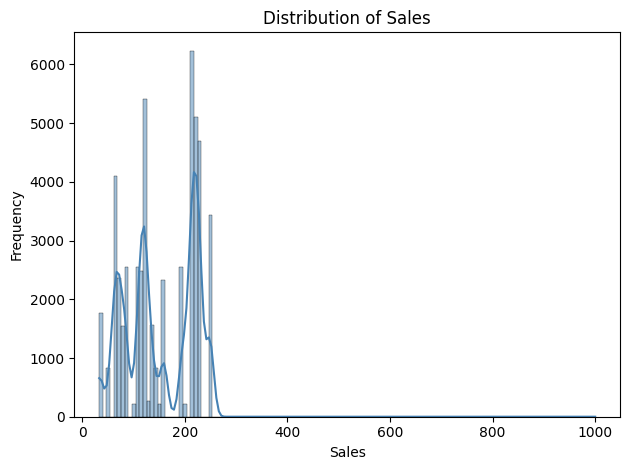

In [11]:
# ── Histogram ──────────────────────────────────────────────────
# Shows the frequency distribution of a continuous variable.
# The KDE (kernel density estimate) curve smooths it into a probability shape.

sns.histplot(df['Sales'], kde=True, color='steelblue')
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

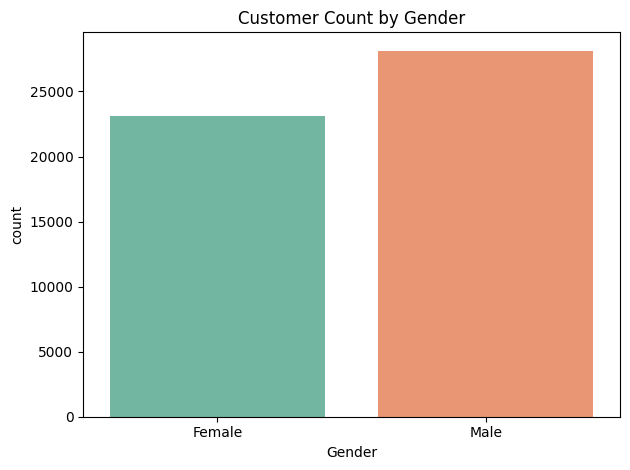

In [12]:
# ── Count Plot ─────────────────────────────────────────────────
# Counts occurrences in each category.
# Here we check whether the dataset is gender-balanced.

sns.countplot(x='Gender', data=df, palette='Set2')
plt.title("Customer Count by Gender")
plt.tight_layout()
plt.show()

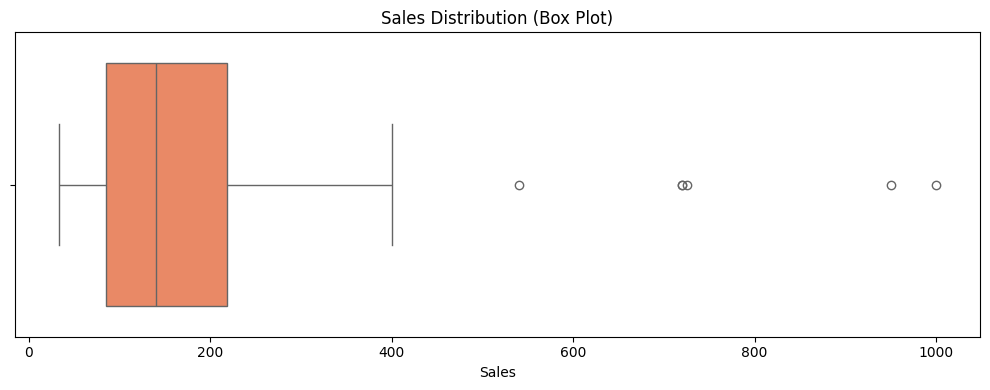

In [13]:
# ── Box Plot ───────────────────────────────────────────────────
# Summarises a distribution into five numbers: min, Q1, median, Q3, max.
# Points beyond the whiskers are potential outliers.

plt.figure(figsize=(10, 4))
sns.boxplot(x='Sales', data=df, color='coral')
plt.title("Sales Distribution (Box Plot)")
plt.tight_layout()
plt.show()

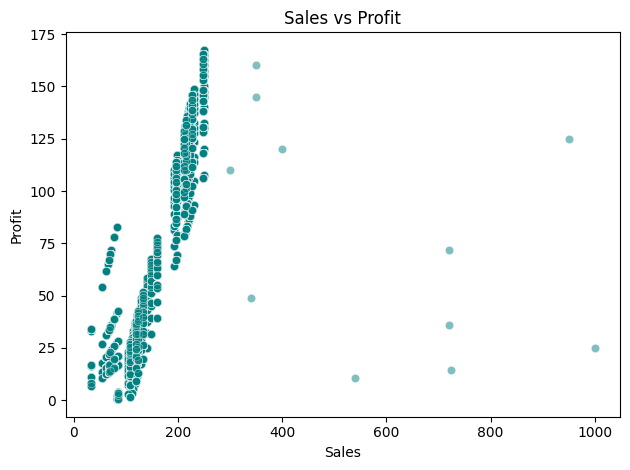

In [14]:
# ── Scatter Plot ───────────────────────────────────────────────
# Reveals the relationship between two continuous variables.
# A positive slope here would suggest that higher sales produce higher profit.

sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.5, color='teal')
plt.title("Sales vs Profit")
plt.tight_layout()
plt.show()

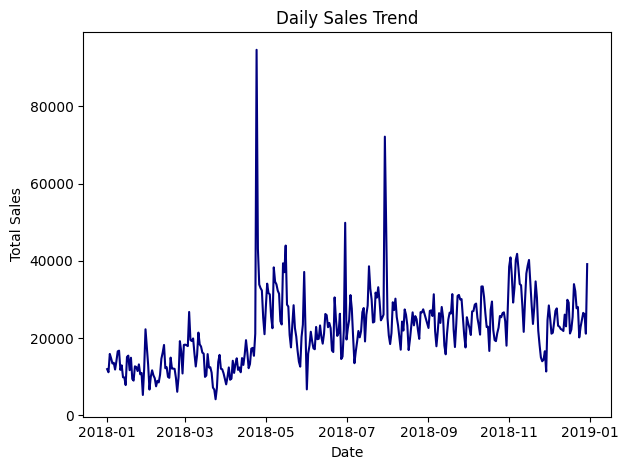

In [15]:
# ── Line Plot ──────────────────────────────────────────────────
# Best suited for showing a trend over time.
# We aggregate daily sales first so the line isn't a noisy mess.

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
daily_sales = df.groupby('Order_Date')['Sales'].sum().reset_index()

sns.lineplot(x='Order_Date', y='Sales', data=daily_sales, color='navy')
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

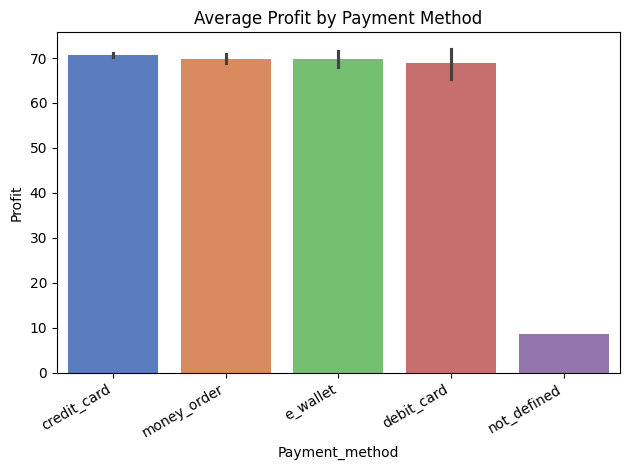

In [16]:
# ── Bar Plot ───────────────────────────────────────────────────
# Compares aggregated values across categories.
# Seaborn defaults to showing the mean — here, average profit per payment method.

sns.barplot(x='Payment_method', y='Profit', data=df, palette='muted')
plt.title("Average Profit by Payment Method")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

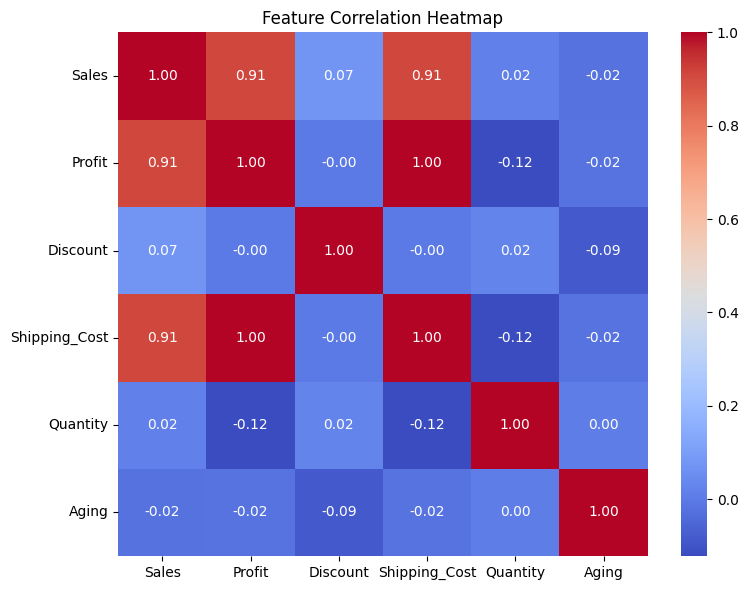

In [17]:
# ── Correlation Heatmap ─────────────────────────────────────────
# The correlation matrix captures pairwise linear relationships (−1 to +1).
# Values close to +1 or −1 indicate strong relationships; near 0 means weak.

numeric_cols = ['Sales', 'Profit', 'Discount', 'Shipping_Cost', 'Quantity', 'Aging']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

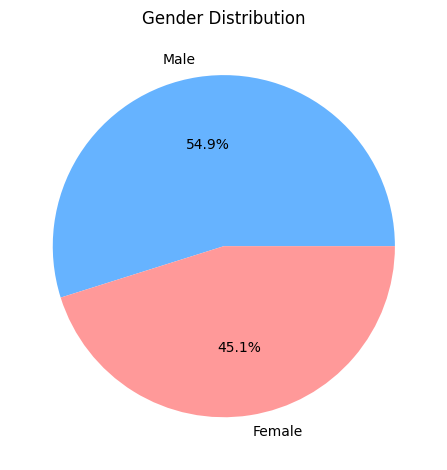

In [18]:
# ── Pie Chart ──────────────────────────────────────────────────
# Shows proportions within a categorical variable.
# Works well when there are only a handful of distinct categories.

gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'])
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

---
## Experiment 3 — Outlier Detection & Treatment

Outliers are data points that sit far from the bulk of the distribution. They can arise from data entry errors, rare genuine events, or measurement noise. Left unchecked, they distort means, inflate variance, and can wreck the assumptions of many ML algorithms.

We cover two detection methods:
- **IQR (Interquartile Range)** — non-parametric, based on percentiles.
- **Z-Score** — parametric, based on standard deviations from the mean.


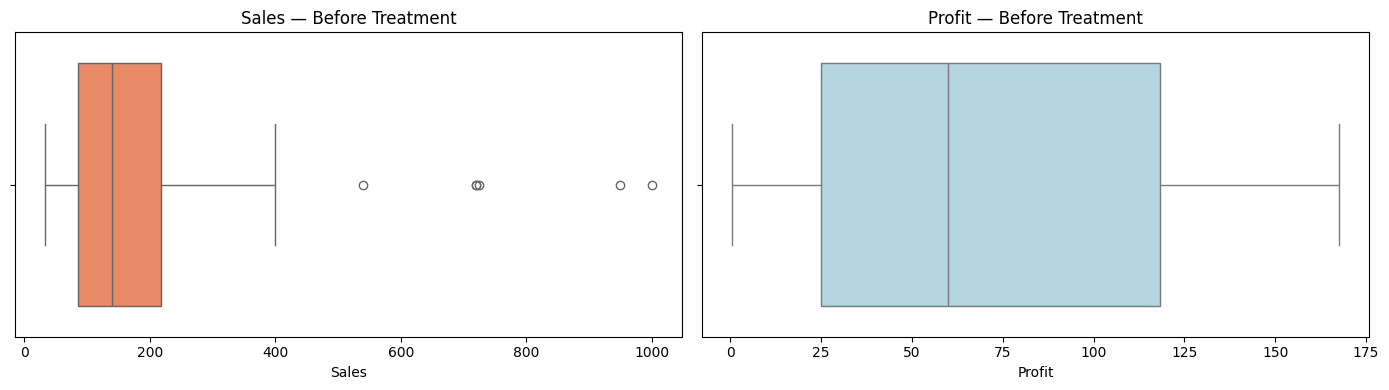

In [19]:
# Work on a copy so the original clean df is preserved for later experiments
df_out = df.copy()

# ── Visual check: are there visible outliers in Sales and Profit? ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df_out['Sales'],  ax=axes[0], color='coral')
axes[0].set_title("Sales — Before Treatment")

sns.boxplot(x=df_out['Profit'], ax=axes[1], color='lightblue')
axes[1].set_title("Profit — Before Treatment")
plt.tight_layout()
plt.show()

### Method 1 — IQR (Interquartile Range)

The IQR spans the middle 50% of the data (Q3 − Q1).  
Outlier boundaries are set as:  
- **Lower limit** = Q1 − 1.5 × IQR  
- **Upper limit** = Q3 + 1.5 × IQR

Any point outside these limits is flagged.


In [20]:
Q1 = df_out['Sales'].quantile(0.25)
Q3 = df_out['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"Q1: {Q1},  Q3: {Q3},  IQR: {IQR:.2f}")
print(f"Lower bound: {lower_iqr:.2f}  |  Upper bound: {upper_iqr:.2f}")
print(f"Outliers detected: {((df_out['Sales'] < lower_iqr) | (df_out['Sales'] > upper_iqr)).sum()}")

Q1: 85.0,  Q3: 218.0,  IQR: 133.00
Lower bound: -114.50  |  Upper bound: 417.50
Outliers detected: 6


In [21]:
# Trim outliers using IQR
df_trimmed_iqr = df_out[(df_out['Sales'] >= lower_iqr) & (df_out['Sales'] <= upper_iqr)]
print(f"Rows before: {len(df_out)}  |  Rows after IQR trimming: {len(df_trimmed_iqr)}")

Rows before: 51290  |  Rows after IQR trimming: 51284


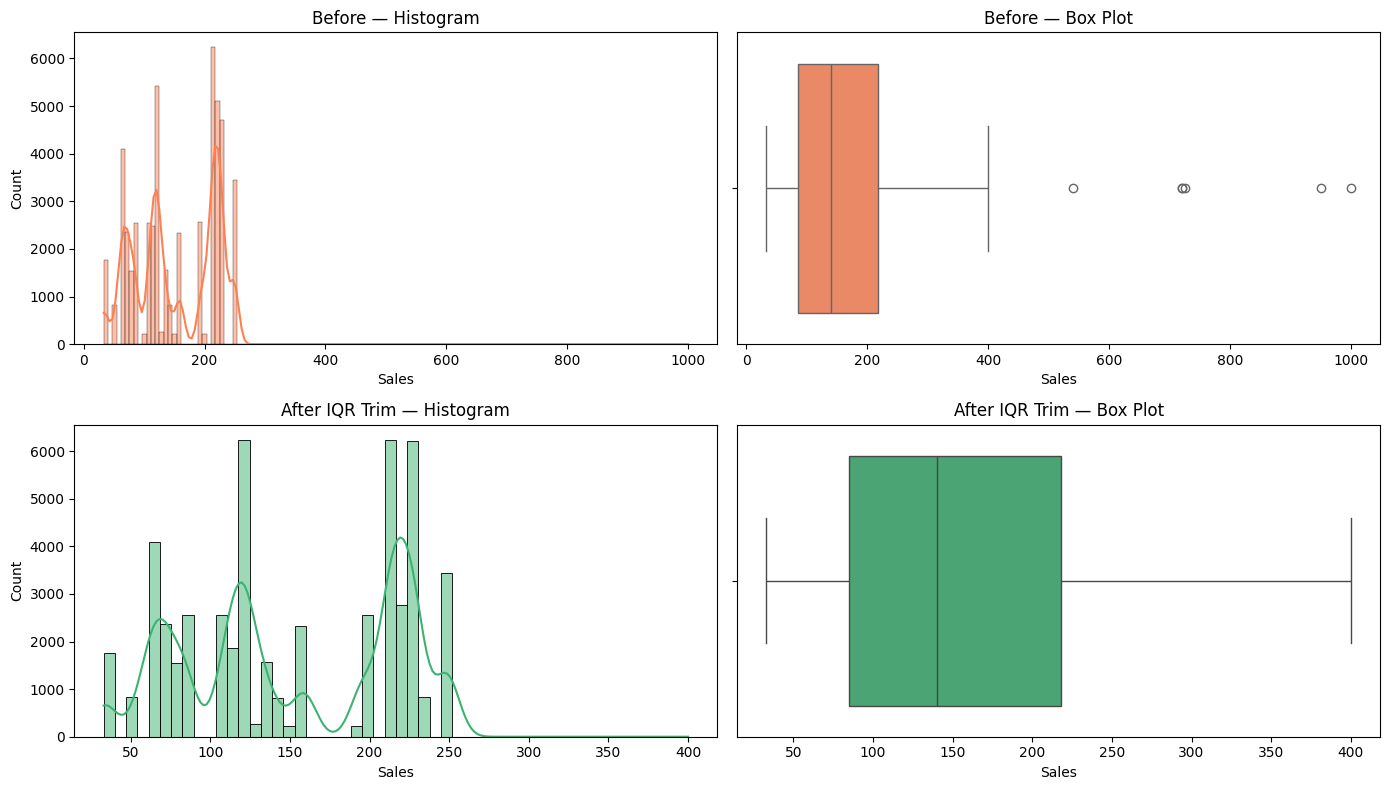

In [22]:
# Visual comparison — before vs after IQR trimming
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df_out['Sales'], kde=True, ax=axes[0,0], color='coral')
axes[0,0].set_title("Before — Histogram")

sns.boxplot(x=df_out['Sales'], ax=axes[0,1], color='coral')
axes[0,1].set_title("Before — Box Plot")

sns.histplot(df_trimmed_iqr['Sales'], kde=True, ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title("After IQR Trim — Histogram")

sns.boxplot(x=df_trimmed_iqr['Sales'], ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title("After IQR Trim — Box Plot")

plt.tight_layout()
plt.show()

### Method 2 — Z-Score

The Z-score measures how many standard deviations a point lies from the mean.  
- **Upper bound** = μ + 3σ  
- **Lower bound** = μ − 3σ  

The ±3σ rule captures ~99.7% of a normally distributed population, so anything beyond it is highly unusual.


In [23]:
mean_sales = df_out['Sales'].mean()
std_sales  = df_out['Sales'].std()

upper_z = mean_sales + 3 * std_sales
lower_z = mean_sales - 3 * std_sales

print(f"Mean: {mean_sales:.2f}  |  Std: {std_sales:.2f}")
print(f"Z-score bounds  →  Lower: {lower_z:.2f}  |  Upper: {upper_z:.2f}")
print(f"Outliers flagged by Z-score: {((df_out['Sales'] < lower_z) | (df_out['Sales'] > upper_z)).sum()}")

Mean: 152.43  |  Std: 66.88
Z-score bounds  →  Lower: -48.20  |  Upper: 353.06
Outliers flagged by Z-score: 7


In [24]:
# Trim using Z-score boundaries
df_trimmed_z = df_out[(df_out['Sales'] >= lower_z) & (df_out['Sales'] <= upper_z)]
print(f"Rows after Z-score trimming: {len(df_trimmed_z)}")

Rows after Z-score trimming: 51283


---
## Experiment 4 — Feature Scaling & Normalization

Machine learning algorithms that rely on distance (k-NN, SVM, clustering) or gradient descent (linear/logistic regression, neural nets) are sensitive to the scale of features. A column with values in the thousands can dominate one with values between 0 and 1, even if the latter is more informative.

Scaling ensures every feature competes on a level playing field. We compare four techniques:

| Technique | Output Range | Sensitive to Outliers? | Best For |
|---|---|---|---|
| Min-Max Scaling | [0, 1] | Yes | Bounded, outlier-free data |
| Standardization (Z-score) | μ=0, σ=1 | Moderate | Normally distributed data |
| Robust Scaling | Median-centred | No | Skewed or outlier-heavy data |
| Normalizer | Unit norm per row | N/A | Text / sparse vectors |


In [25]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer

# Scaling applies only to numerical columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Fill any remaining NaNs (safety net — shouldn't be any after Exp 1)
numeric_df = numeric_df.fillna(numeric_df.mean())

print(f"Numerical features selected: {numeric_df.columns.tolist()}")
numeric_df.head()

Numerical features selected: ['Aging', 'Customer_Id', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost']


,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
0,8.0,37077,140,1.0,0.3,46.0,4.6
1,2.0,59173,211,1.0,0.3,112.0,11.2
2,8.0,41066,117,5.0,0.1,31.2,3.1
3,7.0,50741,118,1.0,0.3,26.2,2.6
4,9.0,53639,250,1.0,0.3,160.0,16.0


In [26]:
# ── Min-Max Scaling ────────────────────────────────────────────
# Formula: X' = (X − X_min) / (X_max − X_min)
# Result: all values compressed into [0, 1]

minmax_df = pd.DataFrame(
    MinMaxScaler().fit_transform(numeric_df),
    columns=numeric_df.columns
)
print("Min-Max Scaled — first 3 rows:")
minmax_df.head(3)

Min-Max Scaled — first 3 rows:


,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
0,0.736842,0.300859,0.110651,0.0,0.5,0.272455,0.269461
1,0.105263,0.546373,0.184074,0.0,0.5,0.667665,0.664671
2,0.736842,0.345182,0.086867,1.0,0.0,0.183832,0.179641


In [27]:
# ── Standardization (Z-score Scaling) ──────────────────────────
# Formula: X' = (X − μ) / σ
# Result: mean = 0, std = 1. Values can be negative.

standard_df = pd.DataFrame(
    StandardScaler().fit_transform(numeric_df),
    columns=numeric_df.columns
)
print("Standardized — first 3 rows:")
standard_df.head(3)

Standardized — first 3 rows:


,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
0,0.927389,-0.809726,-0.185913,-0.994143,-0.029166,-0.500877,-0.501172
1,-1.099713,0.039077,0.875753,-0.994143,-0.029166,0.853553,0.853604
2,0.927389,-0.656491,-0.529833,1.651678,-1.555603,-0.804597,-0.809076


In [28]:
# ── Robust Scaling ─────────────────────────────────────────────
# Formula: X' = (X − median) / IQR
# Because it uses median and IQR instead of mean and std,
# it doesn't get pulled by extreme values.

robust_df = pd.DataFrame(
    RobustScaler().fit_transform(numeric_df),
    columns=numeric_df.columns
)
print("Robust Scaled — first 3 rows:")
robust_df.head(3)

Robust Scaled — first 3 rows:


,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
0,0.6,-0.533148,0.000000,-0.333333,0.0,-0.148663,-0.150538
1,-0.6,-0.041087,0.533835,-0.333333,0.0,0.557219,0.559140
2,0.6,-0.444316,-0.172932,1.000000,-1.0,-0.306952,-0.311828


In [29]:
# ── L2 Normalization (Row-wise) ─────────────────────────────────
# Scales each *row* so that its Euclidean norm equals 1.
# Useful in text processing and sparse data scenarios.

normalized_df = pd.DataFrame(
    Normalizer().fit_transform(numeric_df),
    columns=numeric_df.columns
)
print("L2 Normalized — first 3 rows:")
normalized_df.head(3)

L2 Normalized — first 3 rows:


,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
0,0.000216,0.999992,0.003776,0.000027,0.000008,0.001241,0.000124
1,0.000034,0.999992,0.003566,0.000017,0.000005,0.001893,0.000189
2,0.000195,0.999996,0.002849,0.000122,0.000002,0.000760,0.000075


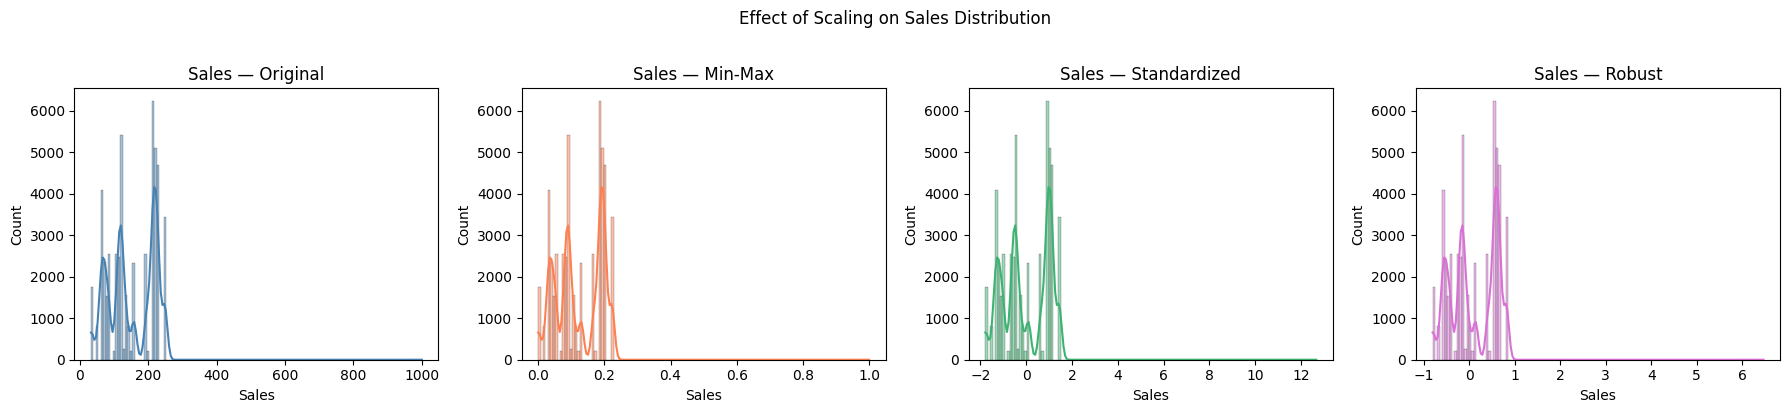

In [30]:
# ── Side-by-side comparison on the 'Sales' column ──────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, data, title, color in zip(
    axes,
    [numeric_df['Sales'], minmax_df['Sales'], standard_df['Sales'], robust_df['Sales']],
    ['Original', 'Min-Max', 'Standardized', 'Robust'],
    ['steelblue', 'coral', 'mediumseagreen', 'orchid']
):
    sns.histplot(data, ax=ax, color=color, kde=True)
    ax.set_title(f"Sales — {title}")

plt.suptitle("Effect of Scaling on Sales Distribution", y=1.02)
plt.tight_layout()
plt.show()

---
## Experiment 5 — Handling Class Imbalance (SMOTE & Ensemble Methods)

Class imbalance is a common problem in real-world datasets — fraud detection, disease diagnosis, spam classification. When one class has far fewer samples than the other, most classifiers simply predict the majority class and still get high accuracy, while completely missing the minority class (which is usually the one you care about).

We explore two solutions:
- **SMOTE** (Synthetic Minority Over-sampling Technique): generates new minority-class samples by interpolating between existing ones.
- **Balanced Bagging Classifier**: an ensemble that internally resamples each bootstrap bag to be balanced.

> A synthetic dataset is used here to clearly demonstrate the imbalance concept, since the e-commerce dataset itself is balanced.


In [31]:
# Install imbalanced-learn if not already present
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.ensemble import BalancedBaggingClassifier
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
    from imblearn.ensemble import BalancedBaggingClassifier

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter

Original class distribution: Counter({np.int64(1): 893, np.int64(0): 107})


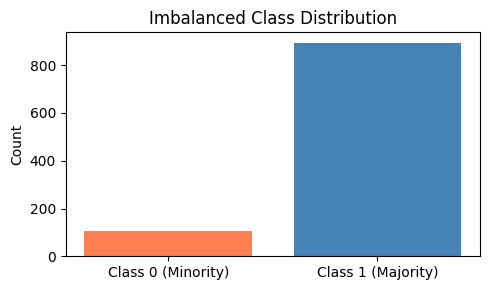

In [32]:
# Create a synthetic dataset with a 10:90 class imbalance
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=3,
    n_redundant=1,
    weights=[0.1, 0.9],   # 10% minority, 90% majority
    class_sep=2,
    random_state=42
)

print("Original class distribution:", Counter(y))

# Visualise the imbalance
plt.figure(figsize=(5, 3))
plt.bar(['Class 0 (Minority)', 'Class 1 (Majority)'],
        [Counter(y)[0], Counter(y)[1]], color=['coral', 'steelblue'])
plt.title("Imbalanced Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [33]:
# Train/test split — keep test set untouched (no resampling on test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training distribution before SMOTE:", Counter(y_train))

Training distribution before SMOTE: Counter({np.int64(1): 711, np.int64(0): 89})


In [34]:
# Apply SMOTE to the training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Training distribution after SMOTE:", Counter(y_train_resampled))

Training distribution after SMOTE: Counter({np.int64(1): 711, np.int64(0): 711})


In [35]:
# Train a Random Forest on the SMOTE-balanced data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_resampled, y_train_resampled)

y_pred_smote = model_smote.predict(X_test)

print("=== SMOTE + Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(classification_report(y_test, y_pred_smote))

=== SMOTE + Random Forest ===
Accuracy: 0.9850
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.98      1.00      0.99       182

    accuracy                           0.98       200
   macro avg       0.99      0.92      0.95       200
weighted avg       0.99      0.98      0.98       200



In [36]:
# Balanced Bagging — handles imbalance internally at the ensemble level
# Each decision tree in the bag sees a balanced bootstrap sample.

model_bb = BalancedBaggingClassifier(
    estimator=RandomForestClassifier(random_state=42),
    random_state=42
)
model_bb.fit(X_train, y_train)

y_pred_bb = model_bb.predict(X_test)

print("=== Balanced Bagging Classifier ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bb):.4f}")
print(classification_report(y_test, y_pred_bb))

=== Balanced Bagging Classifier ===
Accuracy: 0.9850
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       0.98      1.00      0.99       182

    accuracy                           0.98       200
   macro avg       0.99      0.92      0.95       200
weighted avg       0.99      0.98      0.98       200



---
## Experiment 6 — Dataset Partitioning & Statistical Validation (Two-Sample Z-Test)

Splitting data into training and testing sets is one of the most important — and most overlooked — steps in ML. The goal is to train on one portion of the data and evaluate on an unseen portion to get an honest estimate of real-world performance.

But how do we know if the split was done correctly? If training and testing sets come from different statistical populations, any evaluation metric is misleading. A **two-sample Z-test** checks exactly that.

**Hypotheses:**
- **H₀ (Null):** The training and testing sets are drawn from the same population (means are equal).
- **H₁ (Alternative):** The means differ significantly.


In [37]:
from sklearn.model_selection import train_test_split
from scipy import stats

# We test the split on the 'Aging' column as a representative numerical feature
train_data, test_data = train_test_split(df['Aging'], test_size=0.3, random_state=42)

print(f"Training set size : {len(train_data)}")
print(f"Testing set size  : {len(test_data)}")

Training set size : 35903
Testing set size  : 15387


In [38]:
# Compute statistics for both sets
mean_train, mean_test = train_data.mean(), test_data.mean()
std_train,  std_test  = train_data.std(),  test_data.std()
n_train,    n_test    = len(train_data),   len(test_data)

print(f"Train  →  Mean: {mean_train:.4f}  |  Std: {std_train:.4f}")
print(f"Test   →  Mean: {mean_test:.4f}   |  Std: {std_test:.4f}")

Train  →  Mean: 5.2633  |  Std: 2.9638
Test   →  Mean: 5.2358   |  Std: 2.9510


In [39]:
# Two-sample Z-statistic
# Measures how many standard errors separate the two sample means
z_score = (mean_train - mean_test) / np.sqrt(
    (std_train**2 / n_train) + (std_test**2 / n_test)
)

# p-value: probability of observing this z-score (or more extreme) if H₀ is true
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

print(f"Z-Score : {z_score:.4f}")
print(f"P-Value : {p_value:.4f}")

Z-Score : 0.9674
P-Value : 0.3334


In [40]:
alpha = 0.05

if p_value > alpha:
    print(f"Result: Fail to reject H₀  (p={p_value:.4f} > α={alpha})")
    print("The training and testing sets are statistically similar — the split is valid.")
else:
    print(f"Result: Reject H₀  (p={p_value:.4f} ≤ α={alpha})")
    print("Warning: The split may not be representative. Consider re-stratifying.")

Result: Fail to reject H₀  (p=0.3334 > α=0.05)
The training and testing sets are statistically similar — the split is valid.


---
## Experiment 7 — Statistical Hypothesis Testing (T-Test & Chi-Square)

Hypothesis tests let us draw conclusions about populations from sample data. Instead of eyeballing charts, we get a precise probability that an observed difference is genuine or just sampling noise.

Two tests are covered here:

**1. Independent Samples T-Test** — compares the **means** of a continuous variable across two groups.  
Use case: *"Do male and female customers spend different amounts on average?"*

**2. Chi-Square Test of Independence** — checks whether two **categorical** variables are related.  
Use case: *"Is product category preference independent of gender?"*


In [41]:
# ── T-Test: Sales by Gender ─────────────────────────────────────
# H₀: Mean sales for Male and Female customers are equal
# H₁: There is a statistically significant difference

male_sales   = df[df['Gender'] == 'Male']['Sales'].dropna()
female_sales = df[df['Gender'] == 'Female']['Sales'].dropna()

t_stat, p_t = stats.ttest_ind(male_sales, female_sales)

print(f"Male   sales — Mean: {male_sales.mean():.2f}  |  Std: {male_sales.std():.2f}")
print(f"Female sales — Mean: {female_sales.mean():.2f}  |  Std: {female_sales.std():.2f}")
print()
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_t:.4f}")

if p_t < 0.05:
    print("→ Significant difference in sales between genders.")
else:
    print("→ No significant difference in sales between genders.")

Male   sales — Mean: 153.29  |  Std: 66.93
Female sales — Mean: 151.39  |  Std: 66.80

T-Statistic : 3.2048
P-Value     : 0.0014
→ Significant difference in sales between genders.


In [42]:
# ── Chi-Square Test: Gender vs Product Category ─────────────────
# H₀: Gender and Product Category are independent
# H₁: There is a relationship between gender and product category

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Gender'], df['Product_Category'])
print("Contingency Table:")
print(contingency_table)
print()

chi2, p_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-Value              : {p_chi:.4f}")

if p_chi < 0.05:
    print("→ Gender and Product Category are NOT independent (significant association).")
else:
    print("→ Gender and Product Category are independent (no significant association).")

Contingency Table:
Product_Category  Auto & Accessories  Electronic  Fashion  Home & Furniture
Gender                                                                     
Female                          2323        1484    11365              7980
Male                            5182        1217    14281              7458

Chi-Square Statistic : 989.3744
Degrees of Freedom   : 3
P-Value              : 0.0000
→ Gender and Product Category are NOT independent (significant association).


---
## ML Pipeline — Shared Preprocessing (used by Experiments 8 & 9)

Experiments 8 and 9 both require a fully numeric, model-ready DataFrame. Rather than repeating the same preprocessing in each experiment, we build **`df_ml` once** here and reuse it.

Steps:
1. Drop columns that carry no predictive signal (date/time, free-text product names, customer ID).
2. One-hot encode all remaining categorical columns using `get_dummies()`.
3. The result is a clean, fully numerical DataFrame ready to be split into features and targets.


In [43]:
# ── One-time ML preprocessing ──────────────────────────────────
# df is already clean (no nulls, no duplicates) from Experiment 1.
# We only need to drop irrelevant columns and encode categoricals.

DROP_COLS = ['Order_Date', 'Time', 'Customer_Id', 'Product']

df_ml = (
    df
    .drop(columns=DROP_COLS, errors='ignore')
    .pipe(pd.get_dummies, drop_first=True)
)

print(f"ML-ready DataFrame shape: {df_ml.shape}")
print(f"Columns: {df_ml.columns.tolist()}")
print(f"Remaining nulls: {df_ml.isnull().sum().sum()}")
df_ml.head(3)

ML-ready DataFrame shape: (51290, 21)
Columns: ['Aging', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Gender_Male', 'Device_Type_Web', 'Customer_Login_type_Guest', 'Customer_Login_type_Member', 'Customer_Login_type_New ', 'Product_Category_Electronic', 'Product_Category_Fashion', 'Product_Category_Home & Furniture', 'Order_Priority_High', 'Order_Priority_Low', 'Order_Priority_Medium', 'Payment_method_debit_card', 'Payment_method_e_wallet', 'Payment_method_money_order', 'Payment_method_not_defined']
Remaining nulls: 0


,Aging,Sales,Quantity,Discount,Profit,Shipping_Cost,Gender_Male,Device_Type_Web,Customer_Login_type_Guest,Customer_Login_type_Member,...,Product_Category_Electronic,Product_Category_Fashion,Product_Category_Home & Furniture,Order_Priority_High,Order_Priority_Low,Order_Priority_Medium,Payment_method_debit_card,Payment_method_e_wallet,Payment_method_money_order,Payment_method_not_defined
0,8.0,140,1.0,0.3,46.0,4.6,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
1,2.0,211,1.0,0.3,112.0,11.2,False,True,False,True,...,False,False,False,False,False,True,False,False,False,False
2,8.0,117,5.0,0.1,31.2,3.1,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


---
## Experiment 8 — Linear Regression (Predicting Sales)

Linear regression is the simplest and most interpretable supervised learning model. It fits a hyperplane through the training data by minimising the sum of squared residuals.

**Target variable:** `Sales`  
**Evaluation metrics:**
- **MAE** (Mean Absolute Error) — average magnitude of errors; easy to interpret in original units.
- **MSE** (Mean Squared Error) — penalises large errors more heavily.
- **R²** (Coefficient of Determination) — proportion of variance explained (1.0 is perfect; 0 means the model is no better than the mean).


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target for regression
X_reg = df_ml.drop('Sales', axis=1)
y_reg = df_ml['Sales']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Training set : {X_train_r.shape[0]} samples")
print(f"Testing set  : {X_test_r.shape[0]} samples")

Training set : 41032 samples
Testing set  : 10258 samples


In [45]:
# Fit the model
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = lr_model.predict(X_test_r)

print("Model trained successfully.")

Model trained successfully.


In [46]:
# First 10 actual vs predicted values
results_reg = pd.DataFrame({
    'Actual Sales'   : y_test_r.values[:10],
    'Predicted Sales': np.round(y_pred_r[:10], 2)
})
print(results_reg.to_string(index=False))

 Actual Sales  Predicted Sales
          133           112.76
          224           226.70
           72           148.61
           85           108.17
          124            89.65
          111            75.18
          218           231.68
          119            98.87
          224           219.95
          196           187.18


In [47]:
# Evaluation metrics
mae = mean_absolute_error(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)

print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"R²    : {r2:.4f}")

MAE   : 18.8750
MSE   : 633.5838
R²    : 0.8596


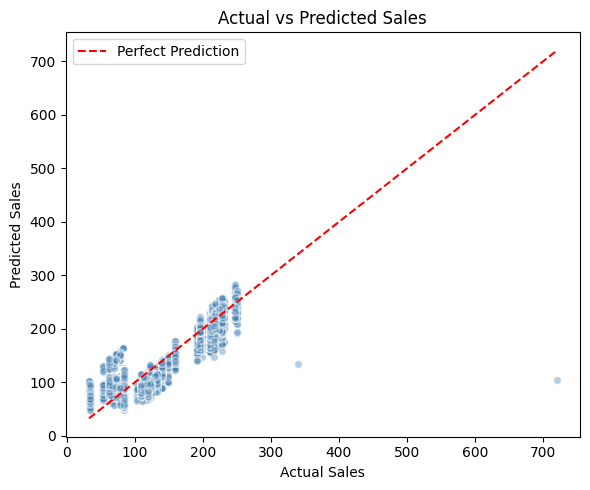

In [48]:
# Actual vs Predicted scatter — points should cluster around the diagonal
plt.figure(figsize=(6, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', lw=1.5, label='Perfect Prediction')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

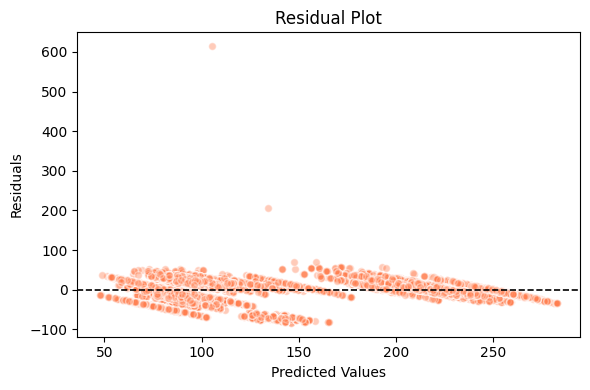

In [49]:
# Residual plot — residuals should be randomly scattered around zero
# Patterns here would indicate model misspecification
residuals = y_test_r.values - y_pred_r

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_r, residuals, alpha=0.4, color='coral', edgecolors='white', s=30)
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

---
## Experiment 9 — Logistic Regression (Classifying Order Priority)

While linear regression predicts a continuous value, logistic regression predicts the **probability** of belonging to a class. It maps the linear combination of features to a [0, 1] range using the sigmoid function.

**Target variable:** `Order_Priority_High` (1 = High priority, 0 = otherwise)  
**Key evaluation metrics for classification:**
- **Precision** — of all predicted positives, how many are correct?
- **Recall** — of all actual positives, how many did we catch?
- **F1-Score** — harmonic mean of precision and recall; better than accuracy alone for imbalanced classes.


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Target column is 'Order_Priority_High' (created during one-hot encoding in Exp 1 preprocessing)
TARGET_CLS = 'Order_Priority_High'

if TARGET_CLS not in df_ml.columns:
    raise KeyError(f"Column '{TARGET_CLS}' not found. Check that 'Order_Priority' had a 'High' category.")

X_cls = df_ml.drop(columns=[TARGET_CLS, 'Sales'], errors='ignore')
y_cls = df_ml[TARGET_CLS]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

print(f"Training set : {X_train_c.shape[0]} samples  |  Class balance: {dict(y_train_c.value_counts())}")
print(f"Testing set  : {X_test_c.shape[0]} samples")

Training set : 41032 samples  |  Class balance: {False: np.int64(28570), True: np.int64(12462)}
Testing set  : 10258 samples


In [51]:
# Standardise features — logistic regression is gradient-based and benefits from scaling
scaler_cls = StandardScaler()
X_train_cs = scaler_cls.fit_transform(X_train_c)
X_test_cs  = scaler_cls.transform(X_test_c)

In [52]:
# Train the classifier
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_cs, y_train_c)

y_pred_c = log_model.predict(X_test_cs)

print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")

Accuracy: 0.9240


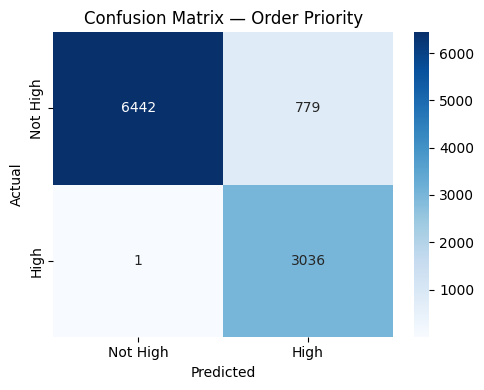

In [53]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High', 'High'],
            yticklabels=['Not High', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Order Priority")
plt.tight_layout()
plt.show()

In [54]:
# Full classification report
print(classification_report(y_test_c, y_pred_c, target_names=['Not High', 'High']))

              precision    recall  f1-score   support

    Not High       1.00      0.89      0.94      7221
        High       0.80      1.00      0.89      3037

    accuracy                           0.92     10258
   macro avg       0.90      0.95      0.91     10258
weighted avg       0.94      0.92      0.93     10258



---
## Experiment 10 — K-Means Clustering

Clustering is unsupervised — there is no target label. The algorithm groups data points by similarity, discovering hidden structure in the dataset.

**K-Means** assigns each point to the nearest centroid, then recalculates centroids, and repeats until stable. It requires us to specify **k** (number of clusters) upfront.

**How do we choose k?** The **Elbow Method** plots WCSS (Within-Cluster Sum of Squares) for different values of k. As k increases, WCSS decreases. The "elbow" — the point where the rate of decrease slows sharply — is the optimal k.


In [55]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use a focused set of numerical business metrics
CLUSTER_COLS = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost']

df_clust = df[CLUSTER_COLS].copy()
df_clust = df_clust.fillna(df_clust.mean())   # safety net

# Scale so that no single feature dominates by virtue of its range
scaler_kms = StandardScaler()
scaled_data = scaler_kms.fit_transform(df_clust)

print(f"Clustering on {len(df_clust)} samples across {len(CLUSTER_COLS)} features.")

Clustering on 51290 samples across 5 features.


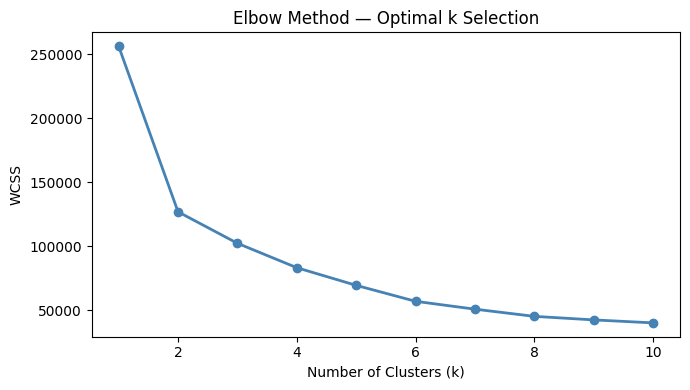

Look for the 'elbow' — the point where WCSS stops dropping steeply.


In [56]:
# ── Elbow Method ───────────────────────────────────────────────
wcss = []
K_RANGE = range(1, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_RANGE, wcss, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Optimal k Selection")
plt.tight_layout()
plt.show()

print("Look for the 'elbow' — the point where WCSS stops dropping steeply.")

In [57]:
# Apply K-Means with k = 3 (elbow is typically at 3 for this dataset)
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clust['Cluster'] = kmeans.fit_predict(scaled_data)

print("Cluster assignments added.")
print(df_clust['Cluster'].value_counts().sort_index().rename("Sample Count"))

Cluster assignments added.
Cluster
0    22160
1    12803
2    16327
Name: Sample Count, dtype: int64


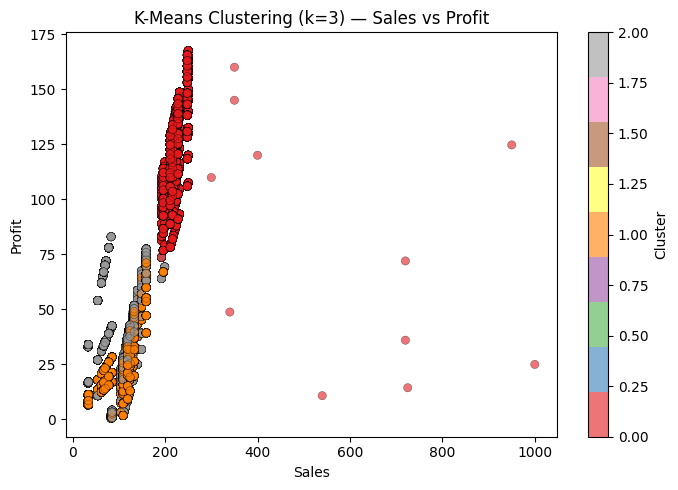

In [58]:
# Cluster visualisation on Sales vs Profit axes
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    df_clust['Sales'], df_clust['Profit'],
    c=df_clust['Cluster'], cmap='Set1', alpha=0.6, edgecolors='k', linewidths=0.3
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title(f"K-Means Clustering (k={OPTIMAL_K}) — Sales vs Profit")
plt.tight_layout()
plt.show()

In [59]:
# Cluster-level summary — what does each group look like on average?
print("Cluster Profiles (Mean Values):")
df_clust.groupby('Cluster')[CLUSTER_COLS].mean().round(2)

Cluster Profiles (Mean Values):


,Sales,Quantity,Discount,Profit,Shipping_Cost
Cluster,,,,,
0,221.78,2.52,0.31,121.91,12.19
1,99.33,4.04,0.30,24.59,2.46
2,99.96,1.28,0.30,36.43,3.65


---
## Experiment 11 — Exploratory Data Analysis with Apache Spark

All previous experiments used **Pandas**, which loads data into a single machine's RAM. That works fine for datasets in the thousands or low millions of rows, but eventually hits a ceiling.

**Apache Spark** is a distributed computing engine designed for large-scale data. It splits the dataset across a cluster (or across CPU cores locally) and processes chunks in parallel. Even on a single machine, Spark's lazy evaluation and columnar processing make it significantly faster for certain operations on large files.

This experiment replicates key EDA operations using PySpark to illustrate how the same concepts translate into a distributed paradigm.


In [60]:
from pyspark.sql import SparkSession

# SparkSession is the entry point for all Spark functionality
spark = (
    SparkSession.builder
    .appName("ECommerce_EDA")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")

Spark version: 4.0.2


In [61]:
# Load the CSV into a Spark DataFrame
# inferSchema=True tells Spark to scan the file and deduce data types automatically
spark_df = spark.read.csv(
    "E-commerce_Dataset.csv",
    header=True,
    inferSchema=True
)

print(f"Rows: {spark_df.count()}  |  Columns: {len(spark_df.columns)}")
spark_df.show(5)

Rows: 51291  |  Columns: 16
+----------+-------------------+-----+-----------+------+-----------+-------------------+------------------+-----------------+-----+--------+--------+------+-------------+--------------+--------------+
|Order_Date|               Time|Aging|Customer_Id|Gender|Device_Type|Customer_Login_type|  Product_Category|          Product|Sales|Quantity|Discount|Profit|Shipping_Cost|Order_Priority|Payment_method|
+----------+-------------------+-----+-----------+------+-----------+-------------------+------------------+-----------------+-----+--------+--------+------+-------------+--------------+--------------+
|02-01-2018|2026-04-28 10:56:33|  8.0|      37077|Female|        Web|             Member|Auto & Accessories|Car Media Players|  140|       1|     0.3|  46.0|          4.6|        Medium|   credit_card|
|24-07-2018|2026-04-28 20:41:37|  2.0|      59173|Female|        Web|             Member|Auto & Accessories|     Car Speakers|  211|       1|     0.3| 112.0|       

In [62]:
# Schema — equivalent to df.info() in Pandas
spark_df.printSchema()

root
 |-- Order_Date: string (nullable = true)
 |-- Time: timestamp (nullable = true)
 |-- Aging: double (nullable = true)
 |-- Customer_Id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Device_Type: string (nullable = true)
 |-- Customer_Login_type: string (nullable = true)
 |-- Product_Category: string (nullable = true)
 |-- Product: string (nullable = true)
 |-- Sales: integer (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount: double (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Shipping_Cost: double (nullable = true)
 |-- Order_Priority: string (nullable = true)
 |-- Payment_method: string (nullable = true)



In [63]:
# Descriptive statistics — equivalent to df.describe()
spark_df.describe(['Sales', 'Profit', 'Discount', 'Shipping_Cost']).show()

+-------+-----------------+-----------------+-------------------+-----------------+
|summary|            Sales|           Profit|           Discount|    Shipping_Cost|
+-------+-----------------+-----------------+-------------------+-----------------+
|  count|            51291|            51291|              51290|            51290|
|   mean|152.4324540367706|70.40636368953703|0.30382140768180016|7.041470072138756|
| stddev| 66.8761569560814|48.72940421262071| 0.1310253348205666|4.871736654850046|
|    min|               33|              0.5|                0.1|              0.1|
|    max|             1000|            167.5|                0.5|             16.8|
+-------+-----------------+-----------------+-------------------+-----------------+



In [64]:
# Group-level aggregation: total sales per product category
print("Total Sales by Product Category:")
(
    spark_df
    .groupBy("Product_Category")
    .sum("Sales")
    .orderBy("sum(Sales)", ascending=False)
    .show()
)

Total Sales by Product Category:
+------------------+----------+
|  Product_Category|sum(Sales)|
+------------------+----------+
|           Fashion|   4345914|
|  Home & Furniture|   1975831|
|Auto & Accessories|   1101930|
|        Electronic|    394738|
+------------------+----------+



In [65]:
# Count customers by gender
print("Customer Count by Gender:")
spark_df.groupBy("Gender").count().show()

Customer Count by Gender:
+------+-----+
|Gender|count|
+------+-----+
|Female|23153|
|  Male|28138|
+------+-----+



In [66]:
# Average profit by payment method
print("Average Profit by Payment Method:")
from pyspark.sql.functions import avg, round as spark_round

(
    spark_df
    .groupBy("Payment_method")
    .agg(spark_round(avg("Profit"), 2).alias("Avg_Profit"))
    .orderBy("Avg_Profit", ascending=False)
    .show()
)

Average Profit by Payment Method:
+--------------+----------+
|Payment_method|Avg_Profit|
+--------------+----------+
|   credit_card|     70.61|
|   money_order|     69.89|
|      e_wallet|     69.81|
|    debit_card|      68.9|
|   not_defined|       8.5|
+--------------+----------+



In [68]:
spark_df.select("Order_Date").distinct().show(20, False)

+----------+
|Order_Date|
+----------+
|04-07-2018|
|04-11-2018|
|08-03-2018|
|23-11-2018|
|03-11-2018|
|08-05-2018|
|11-02-2018|
|17-10-2018|
|13-06-2018|
|09-09-2018|
|13-04-2018|
|03-05-2018|
|16-09-2018|
|07-08-2018|
|18-11-2018|
|21-01-2018|
|20-03-2018|
|28-08-2018|
|27-02-2018|
|21-05-2018|
+----------+
only showing top 20 rows


In [69]:
from pyspark.sql.functions import to_date, sum as spark_sum

(
    spark_df
    .withColumn("Date", to_date("Order_Date", "dd-MM-yyyy"))  # FIXED
    .groupBy("Date")
    .agg(spark_sum("Sales").alias("Total_Sales"))
    .orderBy("Date")
    .show(10)
)

+----------+-----------+
|      Date|Total_Sales|
+----------+-----------+
|2018-01-01|      11988|
|2018-01-02|      11177|
|2018-01-03|      15927|
|2018-01-04|      14778|
|2018-01-05|      13435|
|2018-01-06|      13631|
|2018-01-07|      11873|
|2018-01-08|      14068|
|2018-01-09|      16586|
|2018-01-10|      16763|
+----------+-----------+
only showing top 10 rows


### Conclusion

| Tool | Strengths | Limitations |
|---|---|---|
| **Pandas** | Rich API, fast iteration, great for visualisation | Single-node RAM limit |
| **Apache Spark** | Distributed, handles massive datasets, SQL-compatible | Overhead for small data, steeper learning curve |

In production systems, Pandas is typically used for prototyping and Spark for at-scale pipeline runs. The two are increasingly interoperable through APIs like **Pandas on Spark** (formerly Koalas).


---
## Summary — Full Experiment Pipeline

| # | Experiment | Technique |
|---|---|---|
| 1 | Data Loading & Preprocessing | Pandas, null imputation, deduplication |
| 2 | Data Visualization | Seaborn / Matplotlib — 8 chart types |
| 3 | Outlier Detection & Treatment | IQR method, Z-score method |
| 4 | Feature Scaling | Min-Max, Standardization, Robust, Normalizer |
| 5 | Class Imbalance Handling | SMOTE, Balanced Bagging Classifier |
| 6 | Dataset Partitioning & Validation | Train-Test Split, Two-Sample Z-Test |
| 7 | Hypothesis Testing | Independent T-Test, Chi-Square Test |
| 8 | Supervised Learning — Regression | Linear Regression, MAE / MSE / R² |
| 9 | Supervised Learning — Classification | Logistic Regression, Confusion Matrix |
| 10 | Unsupervised Learning — Clustering | K-Means, Elbow Method |
| 11 | Large-Scale EDA | Apache Spark (PySpark) |
